# EDA 06jul2026
### Imports necesarios para el EDA

In [1]:
import pandas as pd
from sqlalchemy import create_engine
from scipy.stats import chi2_contingency
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
from dotenv import load_dotenv

**NOTA**: Crear .env con variables MYSQL_PASSWORD, MYSQL_HOST, MYSQL_PORT, MYSQL_USER, MYSQL_DATABASE dentro de la propia carpeta SCRIPTS para reejectuar EDA.

El .env está incluido en .gitignore y no se copiará en el repositorio

### Conexión a la BBDD
 

In [2]:
load_dotenv(dotenv_path=".env") 
MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
MYSQL_HOST = os.getenv("MYSQL_HOST")
MYSQL_PORT = os.getenv("MYSQL_PORT")
MYSQL_USER = os.getenv("MYSQL_USER")
MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")

In [3]:
# Crear motor de conexión
engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
)

### Carga dataset
**NOTA**: cambiar nombre tabla para reejecutar semanalmente

In [4]:
table = "RRHH_CLEAN_07072026"

In [5]:
with engine.connect():
    query = f"SELECT * FROM {table};"
    df = pd.read_sql(query, engine)

### Dimensiones dataset

In [6]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 805
Columnas: 26


### Muestra del dataset

In [7]:
# Muestra de las cinco primeras filas del DataFrame
df.head()

,ID_Absence,ID_Employee,Reason_Absence,Reason_Absence_Desc,Month_Absence,Day_Week,Day_Week_Desc,Seasons,Season_Desc,Transportation_Expense,...,Education,Education_Desc,Son,Social_Drinker,Social_Smoker,Pet,Weight,Height,Body_Mass_Index,Absenteeism_Hours
0,0,14,11,Enfermedades del sistema digestivo,11,2,Lunes,4,Otoño,155.0,...,1,Educación secundaria,2,1,0,0,95,196,25,120
1,1,36,13,Enfermedades del sistema musculoesquelético,4,4,Miércoles,2,Primavera,118.0,...,1,Educación secundaria,1,1,0,0,98,178,31,120
2,2,9,6,Enfermedades del sistema nervioso,7,3,Martes,3,Verano,228.0,...,1,Educación secundaria,2,0,0,1,65,172,22,120
3,3,28,9,Enfermedades del sistema circulatorio,7,3,Martes,3,Verano,225.0,...,1,Educación secundaria,1,0,0,2,69,169,24,112
4,4,9,12,Enfermedades de la piel,3,3,Martes,2,Primavera,228.0,...,1,Educación secundaria,2,0,0,1,65,172,22,112


In [8]:
# Muestra de cinco filas aleatorias del DataFrame
df.sample(5, random_state=42) # random_state muestra mismas filas ejecutadas x primera vez

,ID_Absence,ID_Employee,Reason_Absence,Reason_Absence_Desc,Month_Absence,Day_Week,Day_Week_Desc,Seasons,Season_Desc,Transportation_Expense,...,Education,Education_Desc,Son,Social_Drinker,Social_Smoker,Pet,Weight,Height,Body_Mass_Index,Absenteeism_Hours
192,192,1,1,Enfermedades infecciosas y parasitarias,5,2,Lunes,2,Primavera,235.0,...,3,Postgrado,1,0,0,1,88,172,29,8
718,719,50,10,Enfermedades del sistema respiratorio,5,2,Lunes,2,Primavera,235.0,...,3,Postgrado,0,0,0,0,75,178,25,8
168,168,20,26,Ausencia injustificada,12,4,Miércoles,1,Invierno,260.0,...,1,Educación secundaria,4,1,0,0,65,168,23,8
522,522,28,23,Consulta médica,11,6,Viernes,4,Otoño,225.0,...,1,Educación secundaria,1,0,0,2,69,169,24,2
536,536,29,28,Consulta dental,2,6,Viernes,1,Invierno,225.0,...,4,Máster o doctorado,2,1,0,2,94,182,28,2


### Tipos de datos

In [9]:
tipos_datos = pd.DataFrame({
    "tipo_dato": df.dtypes.astype(str),
    "valores_unicos": df.nunique(),
    "valores_no_nulos": df.notna().sum(),
    "valores_nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100).round(2)
}).reset_index().rename(columns={"index": "columna"})

tipos_datos

,columna,tipo_dato,valores_unicos,valores_no_nulos,valores_nulos,porcentaje_nulos
0,ID_Absence,int64,805,805,0,0.0
1,ID_Employee,int64,136,805,0,0.0
2,Reason_Absence,int64,28,805,0,0.0
3,Reason_Absence_Desc,object,28,805,0,0.0
4,Month_Absence,int64,13,805,0,0.0
5,Day_Week,int64,5,805,0,0.0
6,Day_Week_Desc,object,5,805,0,0.0
7,Seasons,int64,5,805,0,0.0
8,Season_Desc,object,5,805,0,0.0
9,Transportation_Expense,float64,24,805,0,0.0


### Duplicados

In [10]:
duplicados_detalle = df[df.duplicated(keep=False)].sort_values(list(df.columns))
print(f"Registros involucrados en duplicados completos: {len(duplicados_detalle)}")
duplicados_detalle.head(10)

Registros involucrados en duplicados completos: 0


,ID_Absence,ID_Employee,Reason_Absence,Reason_Absence_Desc,Month_Absence,Day_Week,Day_Week_Desc,Seasons,Season_Desc,Transportation_Expense,...,Education,Education_Desc,Son,Social_Drinker,Social_Smoker,Pet,Weight,Height,Body_Mass_Index,Absenteeism_Hours


In [11]:
duplicados = df.duplicated().sum()

print(f"Filas duplicadas: {duplicados}")
print(f"Porcentaje duplicado: {duplicados / len(df) * 100:.2f}%")


Filas duplicadas: 0
Porcentaje duplicado: 0.00%


### Clasificación de variables en categórica y númericas ( discretas y continuas )

In [12]:
variables_categoricas = [
    'Reason_Absence', 'Month_Absence', 'Day_Week', 'Seasons', 'Education'
]

variables_booleanas = ['Disciplinary_Failure', 'Social_Drinker', 'Social_Smoker']

variables_discretas = ['Son', 'Pet' ]

variables_continuas = [
    'Transportation_Expense', 'Distance_Residence_Work', 'Work_load_Average_Day', 'Age', 
    'Hit_Target', 'Weight', 'Height', 'Body_Mass_Index', 'Absenteeism_Hours', 'Service_Time'
]


### Conversiones de datos para facilitar el EDA

In [13]:
# Convertir las columnas "Son" y "Pet" a tipo int para que puedan ser utilizadas como numéricas.

df['Son'] = df['Son'].astype(int)
df['Pet'] = df['Pet'].astype(int)


# Convertir la columna "Work_load_Average_Day" a tipo float para que pueda ser utilizada como númerica.

df["Work_load_Average_Day"] = (
    df["Work_load_Average_Day"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# Convertir las columnas categóricas a tipo "category".

for col in variables_categoricas:
    df[col] = df[col].astype("category")

### Analisis Estadístico 

#### Variables númericas

In [14]:
df.columns

Index(['ID_Absence', 'ID_Employee', 'Reason_Absence', 'Reason_Absence_Desc',
       'Month_Absence', 'Day_Week', 'Day_Week_Desc', 'Seasons', 'Season_Desc',
       'Transportation_Expense', 'Distance_Residence_Work', 'Service_Time',
       'Age', 'Work_load_Average_Day', 'Hit_Target', 'Disciplinary_Failure',
       'Education', 'Education_Desc', 'Son', 'Social_Drinker', 'Social_Smoker',
       'Pet', 'Weight', 'Height', 'Body_Mass_Index', 'Absenteeism_Hours'],
      dtype='object')

In [15]:
variables_numericas = variables_discretas + variables_continuas

df[variables_numericas].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Son,805.0,1.06,1.11,0.00,0.00,1.0,2.00,4.00
Pet,805.0,0.76,1.32,0.00,0.00,0.0,1.00,8.00
Transportation_Expense,805.0,222.86,68.05,118.00,179.00,225.0,260.00,388.00
Distance_Residence_Work,805.0,29.25,14.70,5.00,16.00,26.0,49.00,52.00
Work_load_Average_Day,805.0,271.53,39.12,205.92,244.39,264.6,284.85,378.88
Age,805.0,36.50,6.60,27.00,31.00,37.0,40.00,58.00
Hit_Target,805.0,94.63,3.73,81.00,93.00,95.0,97.00,100.00
Weight,805.0,79.07,12.86,56.00,69.00,80.0,89.00,108.00
Height,805.0,172.28,6.12,163.00,169.00,171.0,172.00,196.00
Body_Mass_Index,805.0,26.63,4.26,19.00,24.00,25.0,31.00,38.00


#### Variables categóricas

In [16]:
df[variables_categoricas+variables_booleanas].describe().T

,count,mean,std,min,25%,50%,75%,max
Disciplinary_Failure,805.0,0.057143,0.232260,0.0,0.0,0.0,0.0,1.0
Social_Drinker,805.0,0.567702,0.495703,0.0,0.0,1.0,1.0,1.0
Social_Smoker,805.0,0.077019,0.266787,0.0,0.0,0.0,0.0,1.0


### Visualizaciones

In [17]:
sns.set_theme(style="whitegrid")

#### Distribución Numéricas Continuas

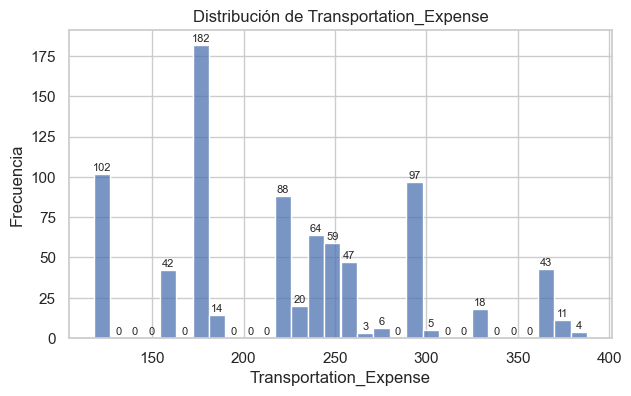

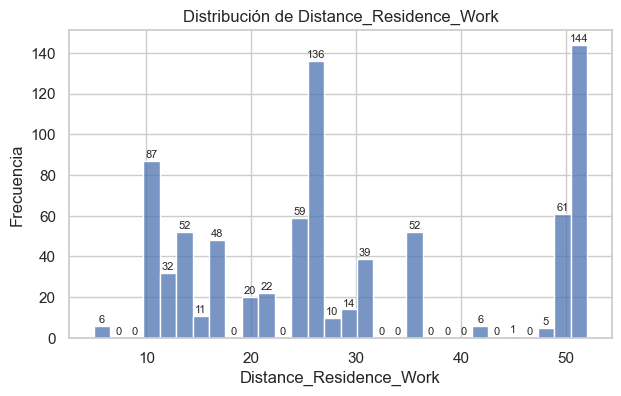

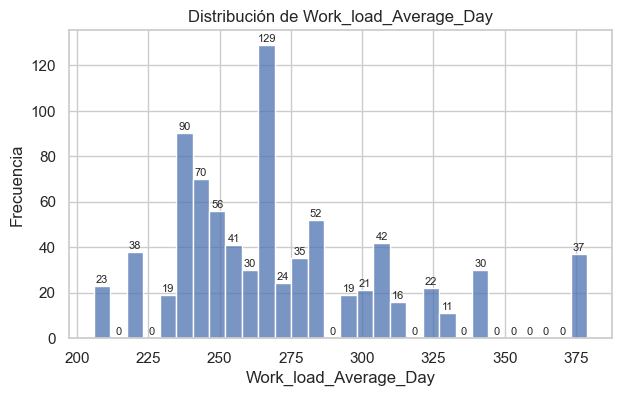

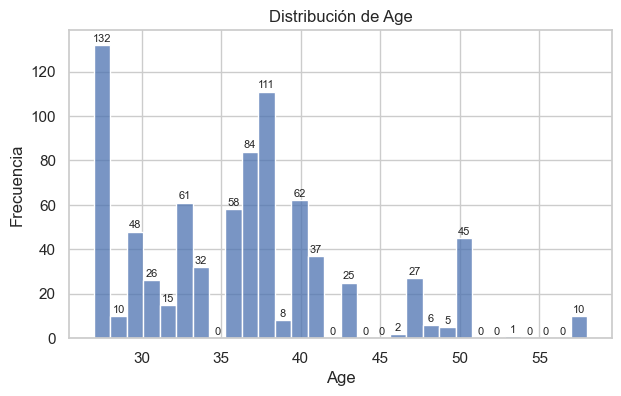

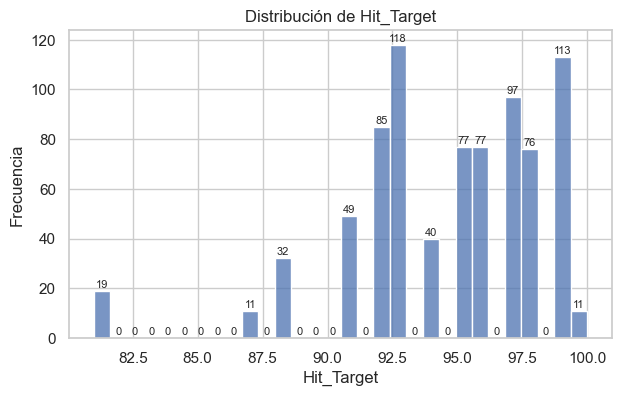

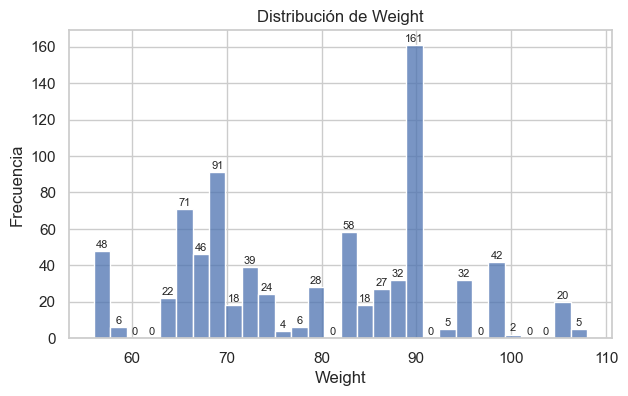

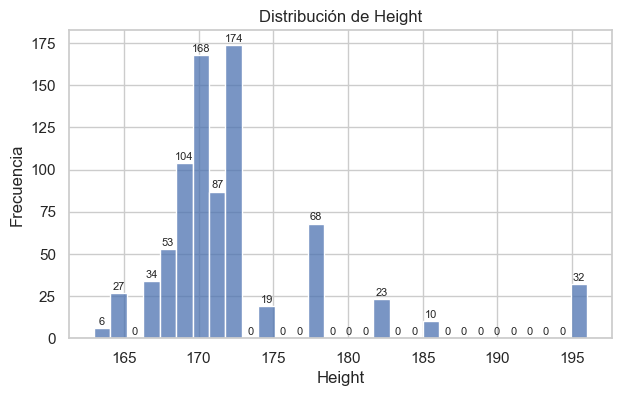

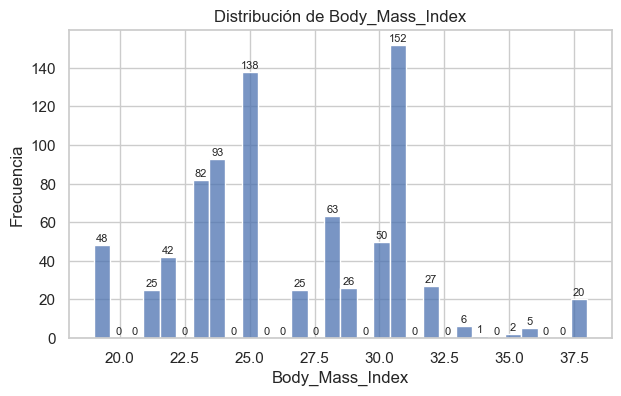

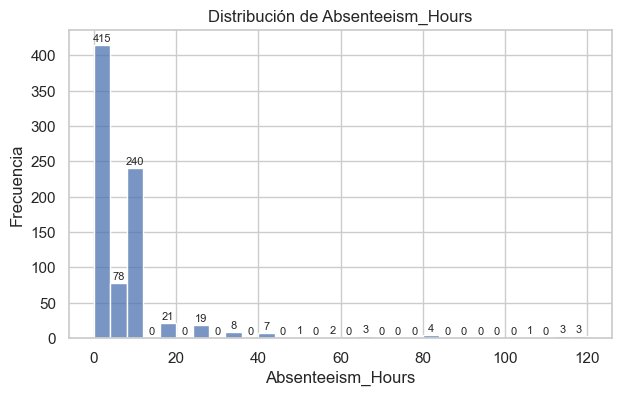

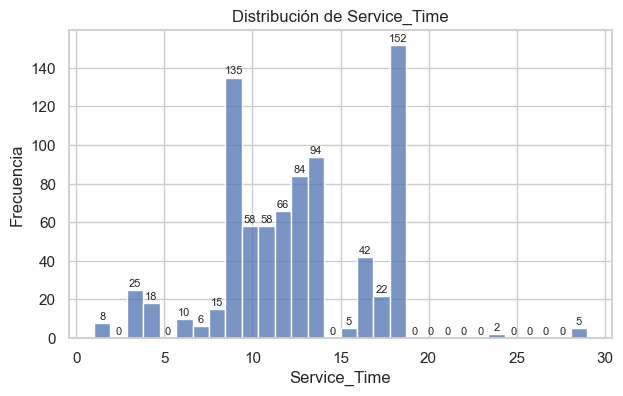

In [18]:
for col in variables_continuas:
    plt.figure(figsize=(7, 4))
    ax =sns.histplot(data=df, x=col, bins=30)

    ax.bar_label(ax.containers[0], padding=1, fontsize=8)

    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

#### Distribución númericas discretas

,Son,frecuencia,porcentaje
0,0,310,38.51
1,1,250,31.06
2,2,180,22.36
3,3,18,2.24
4,4,47,5.84


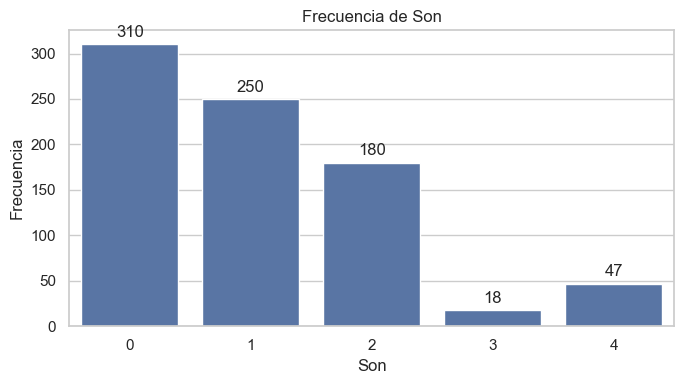

,Pet,frecuencia,porcentaje
0,0,493,61.24
1,1,158,19.63
2,2,103,12.80
3,4,36,4.47
4,5,6,0.75
5,8,9,1.12


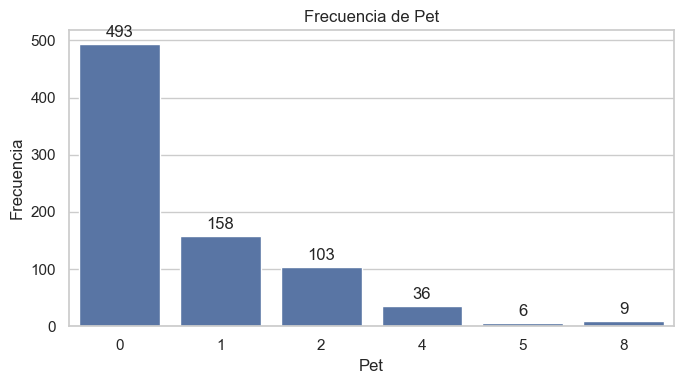

In [19]:
for col in variables_discretas:
    tabla_frecuencia = (
        df[col]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis(col)
        .reset_index(name="frecuencia")
    )
    
    tabla_frecuencia["porcentaje"] = (
        tabla_frecuencia["frecuencia"] / len(df) * 100
    ).round(2)
    
    display(tabla_frecuencia)
    
    plt.figure(figsize=(7, 4))
    ax = sns.barplot(data=tabla_frecuencia, x=col, y="frecuencia")
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3)

    plt.title(f"Frecuencia de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

#### Detección de Outliers (continuas)

##### Resumen cuantitativo de outliers

In [20]:
resumen_outliers = []

for col in variables_continuas:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    mascara = (df[col] < limite_inferior) | (df[col] > limite_superior)

    resumen_outliers.append({
        "variable": col,
        "limite_inferior": round(limite_inferior, 2),
        "limite_superior": round(limite_superior, 2),
        "n_outliers": int(mascara.sum()),
        "porcentaje_outliers": round(mascara.mean() * 100, 2),
        "min": df[col].min(),
        "max": df[col].max()
    })

resumen_outliers = pd.DataFrame(resumen_outliers).sort_values("porcentaje_outliers", ascending=False)
resumen_outliers


,variable,limite_inferior,limite_superior,n_outliers,porcentaje_outliers,min,max
6,Height,164.50,176.50,139,17.27,163.000,196.000
8,Absenteeism_Hours,-7.00,17.00,51,6.34,0.000,120.000
2,Work_load_Average_Day,183.69,345.55,37,4.60,205.917,378.884
4,Hit_Target,87.00,103.00,19,2.36,81.000,100.000
3,Age,17.50,53.50,10,1.24,27.000,58.000
9,Service_Time,-1.50,26.50,5,0.62,1.000,29.000
0,Transportation_Expense,57.50,381.50,4,0.50,118.000,388.000
1,Distance_Residence_Work,-33.50,98.50,0,0.00,5.000,52.000
5,Weight,39.00,119.00,0,0.00,56.000,108.000
7,Body_Mass_Index,13.50,41.50,0,0.00,19.000,38.000


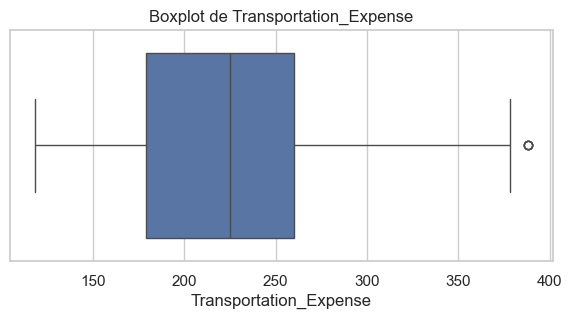

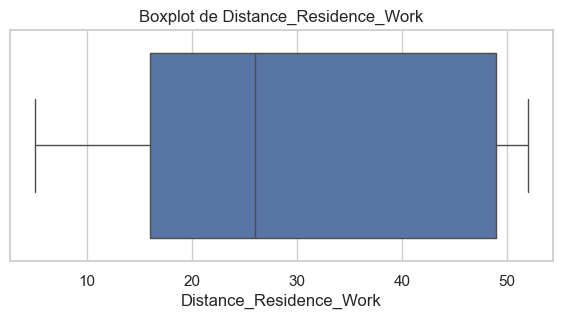

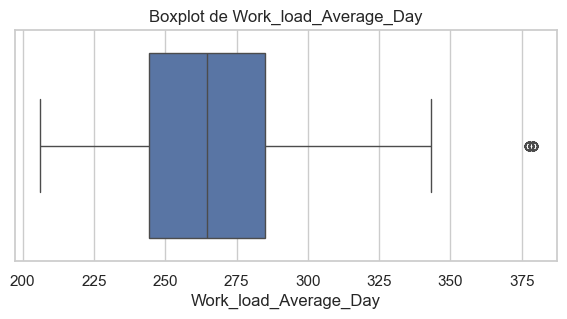

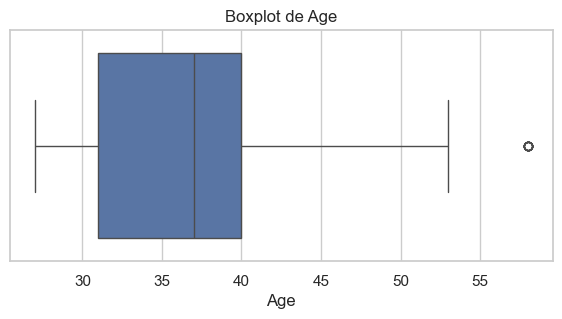

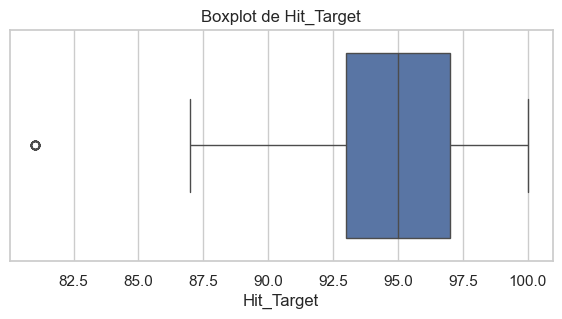

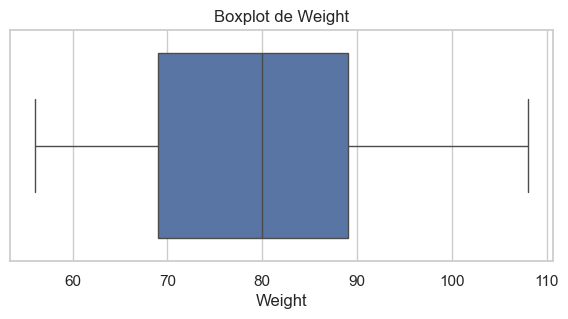

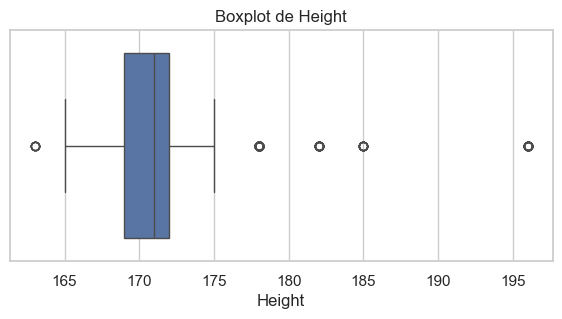

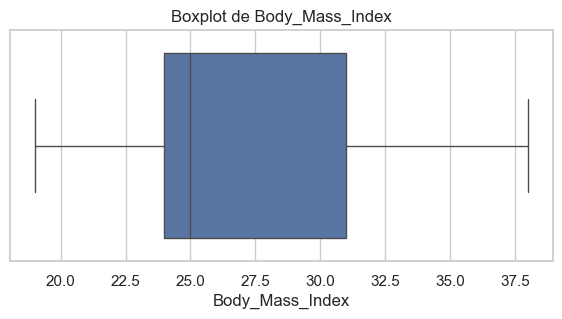

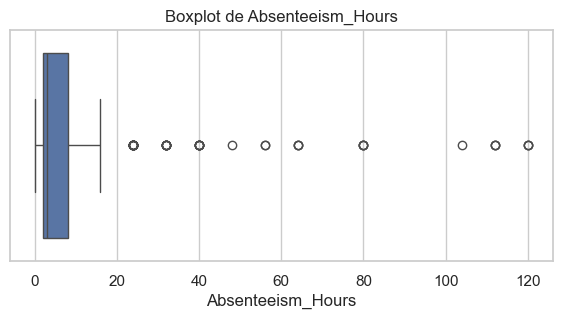

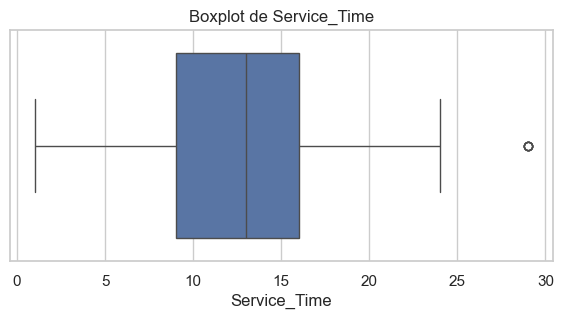

In [21]:
for col in variables_continuas:
    plt.figure(figsize=(7, 3))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

#### Frecuencias Categóricas

In [22]:
ordenes_categoricas = {
    "Month_Absence": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    "Day_Week": [2, 3, 4, 5, 6],
    "Seasons": [1, 2, 3, 4],
    "Education": [1, 2, 3, 4]

}

diccionario_categoricas = {
    "Month_Absence": {
        0:"Sin mes",
        1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr",
        5: "May", 6: "Jun", 7: "Jul", 8: "Ago",
        9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"
    },
    "Day_Week": {
        2: "Lun", 3: "Mar", 4: "Mié", 5: "Jue", 6: "Vie"
    },
    "Seasons": {
        1: "Invierno", 2: "Primavera", 3: "Verano", 4: "Otoño"
    },
    "Education": {
        1: "Secundaria", 2: "Graduado", 3: "Postgrado", 4: "Master o doctorado"
    }

}

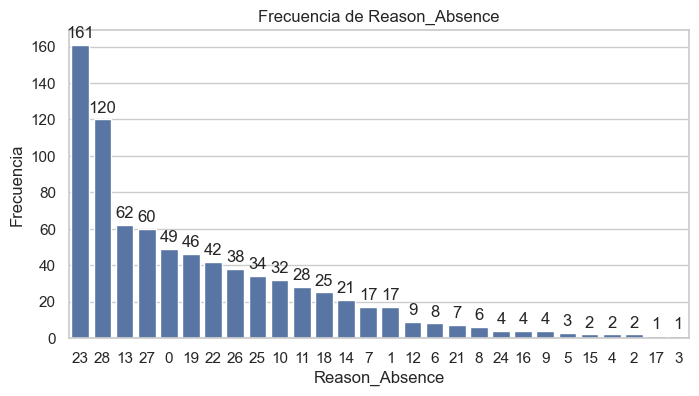

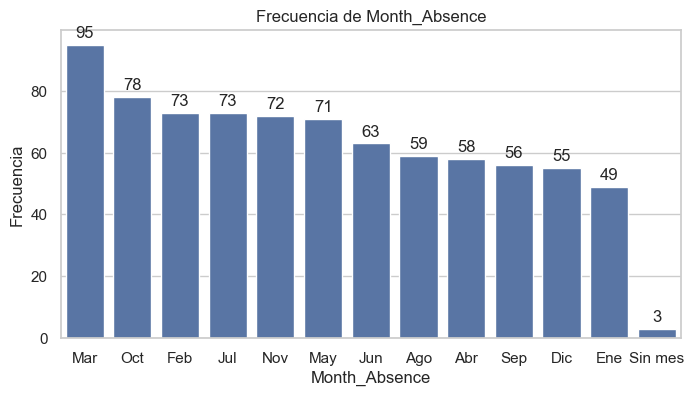

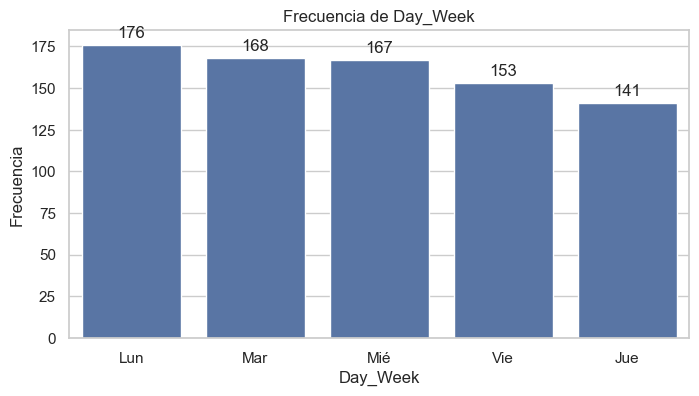

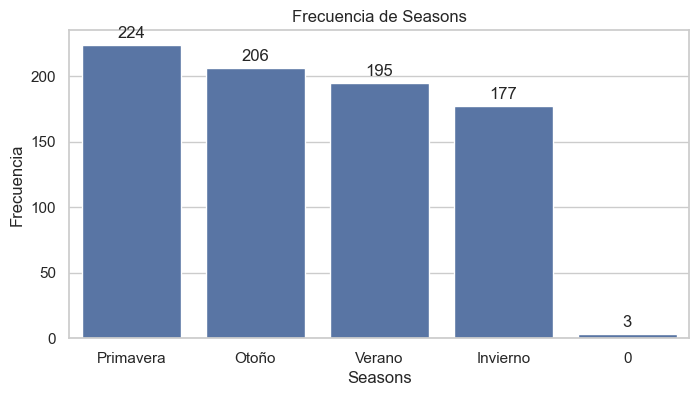

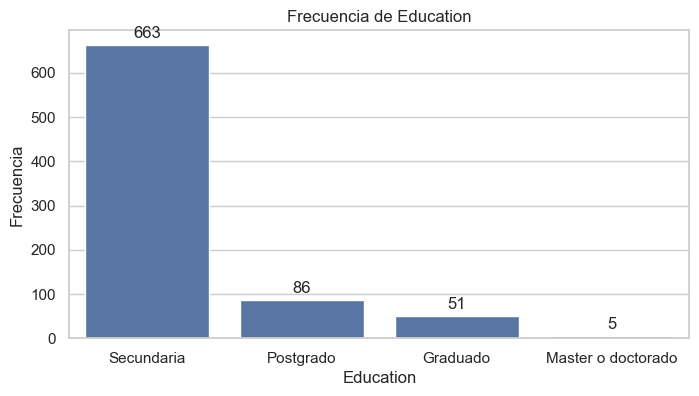

In [23]:
for col in variables_categoricas:
    plt.figure(figsize=(8, 4))
    orden = df[col].value_counts().index
    ax =sns.countplot(data=df, x=col, order=orden)
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3)

    if col in diccionario_categoricas:
        labels = [diccionario_categoricas[col].get(x, x) for x in orden]
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels)

    plt.title(f"Frecuencia de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=0)
    plt.show()

#### Porcentaje Booleanas

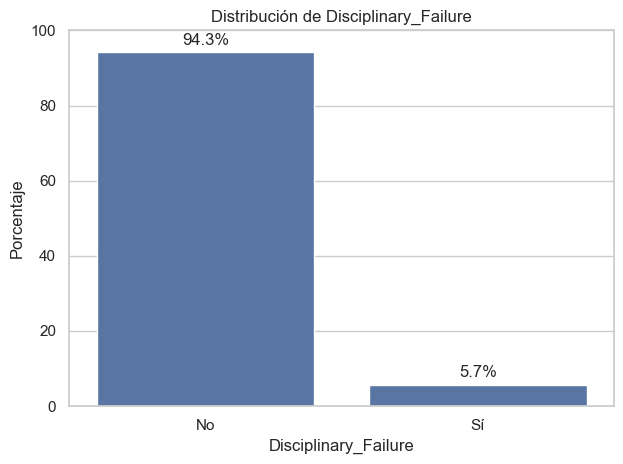

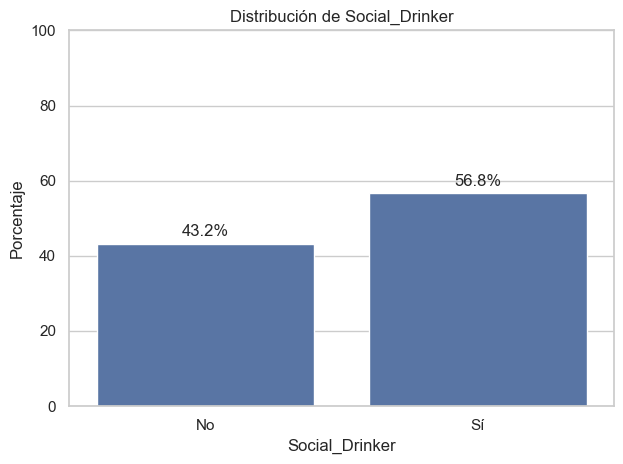

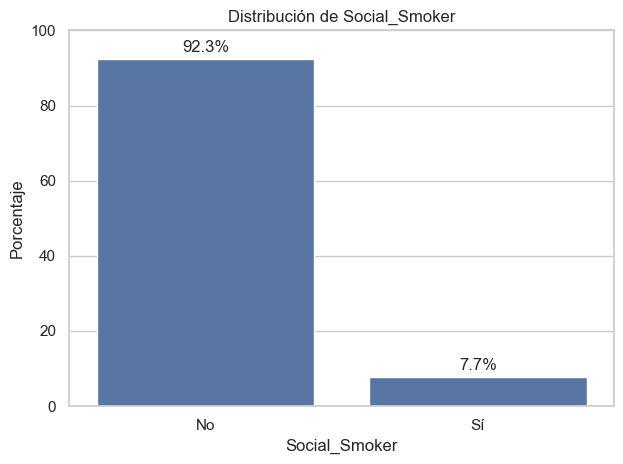

In [24]:
for col in variables_booleanas:
    serie = pd.to_numeric(df[col], errors="coerce")
    tabla = (
        serie
        .map({0: "No", 1: "Sí"})
        .value_counts(normalize=True)
        .mul(100)
        .reindex(["No", "Sí"])
        .reset_index()
    )

    tabla.columns = [col, "porcentaje"]

    ax = sns.barplot(data=tabla, x=col, y="porcentaje")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3)

    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Porcentaje")
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

#### Relaciones entre variables

##### Gráficos de dispersión

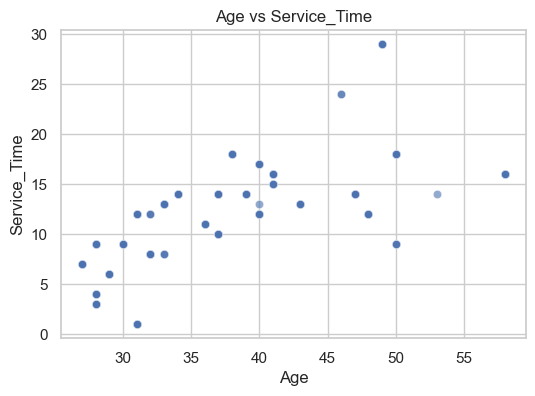

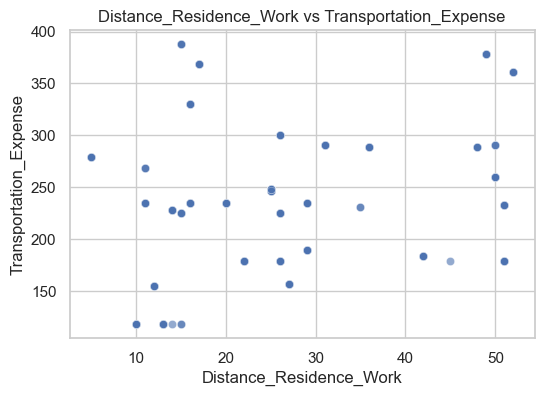

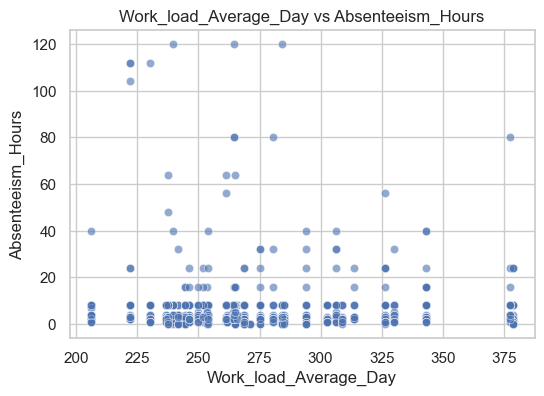

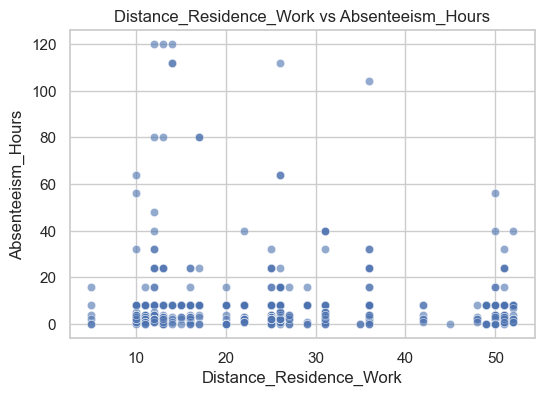

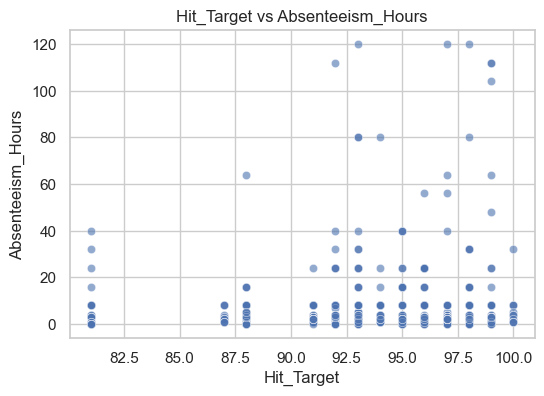

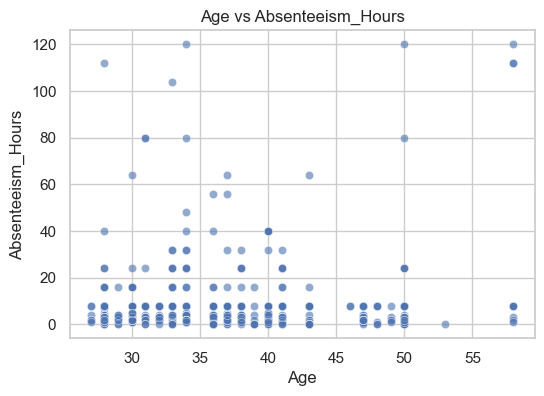

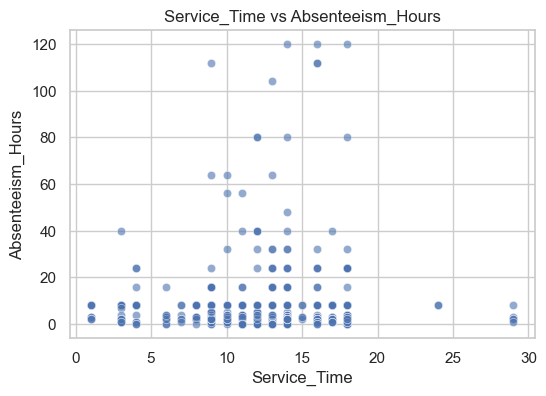

In [25]:
pares_dispersion = [
    ("Age", "Service_Time"),
    ("Distance_Residence_Work", "Transportation_Expense"),
    ("Work_load_Average_Day", "Absenteeism_Hours"),
    ("Distance_Residence_Work", "Absenteeism_Hours"),
    ("Hit_Target", "Absenteeism_Hours"),
    ("Age", "Absenteeism_Hours"),
    ("Service_Time", "Absenteeism_Hours")
]

for x, y in pares_dispersion:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=x, y=y, alpha=0.6)
    plt.title(f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

##### Matriz de correlación

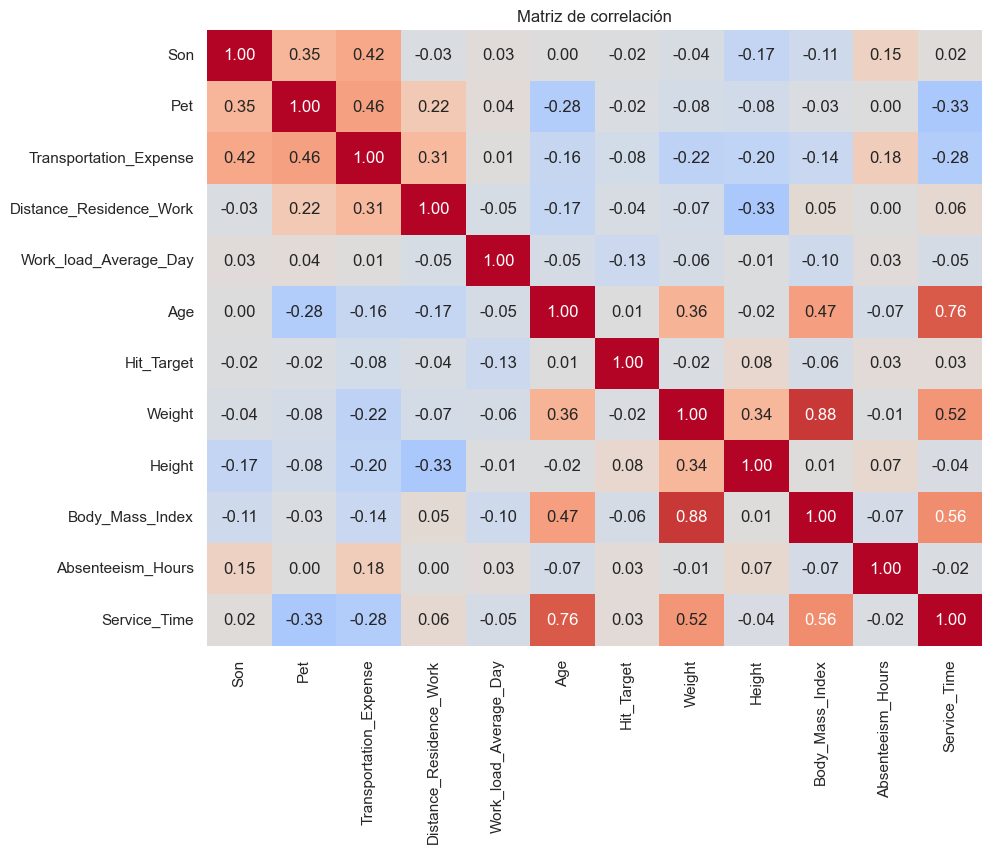

In [26]:
variables_correlacion = variables_discretas + variables_continuas

matriz_correlacion = df[variables_correlacion].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    cbar=False
)
plt.title("Matriz de correlación")
plt.show()

##### Cruce de categóricas


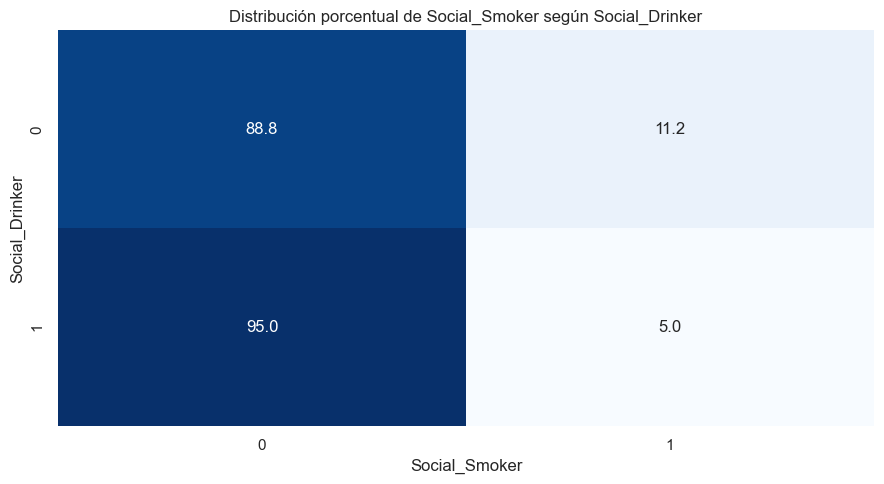

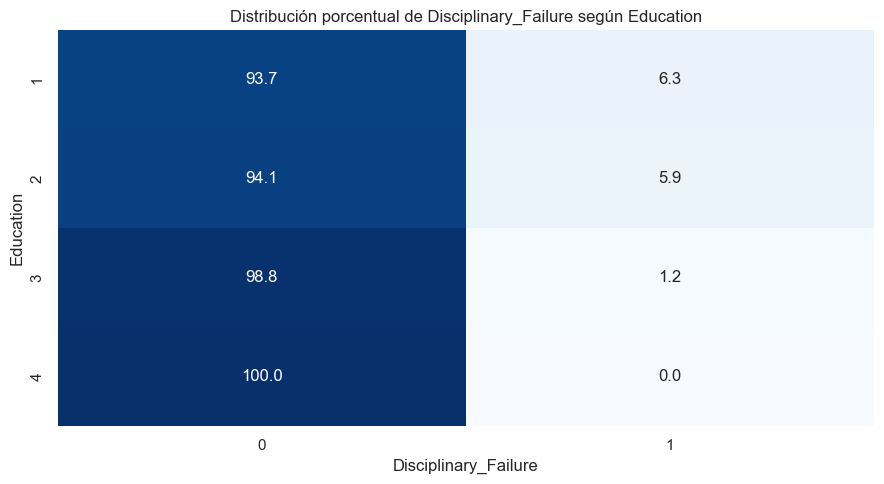

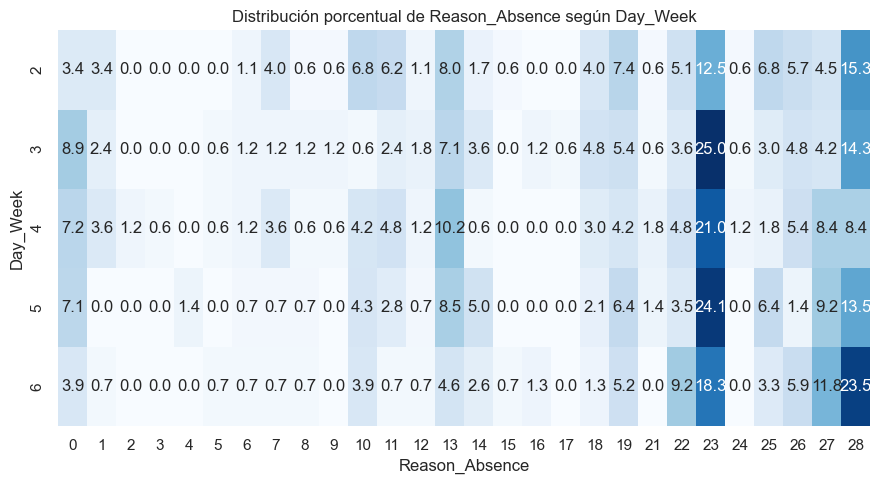

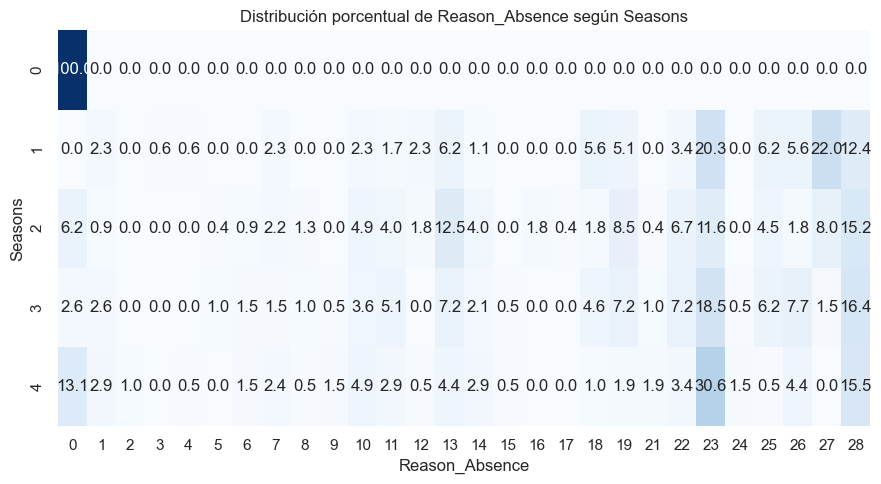

In [27]:
pares_categoricos = [
    ("Social_Drinker", "Social_Smoker"),
    ("Education", "Disciplinary_Failure"),
    ("Day_Week", "Reason_Absence"),
    ("Seasons", "Reason_Absence")
]

for col1, col2 in pares_categoricos:
    tabla_porcentaje = pd.crosstab(
        df[col1],
        df[col2],
        normalize="index"
    ) * 100

    plt.figure(figsize=(9, 5))
    sns.heatmap(
        tabla_porcentaje,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        cbar=False
    )

    plt.title(f"Distribución porcentual de {col2} según {col1}")
    plt.xlabel(col2)
    plt.ylabel(col1)
    plt.tight_layout()
    plt.show()

In [28]:
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape

    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

asociaciones_categoricas = []

variables_asociaciones = variables_categoricas + variables_booleanas

for i, col1 in enumerate(variables_asociaciones):
    for col2 in variables_asociaciones[i+1:]:
        asociaciones_categoricas.append({
            "variable_1": col1,
            "variable_2": col2,
            "cramers_v": cramers_v(df[col1], df[col2])
        })

asociaciones_categoricas = pd.DataFrame(asociaciones_categoricas)

asociaciones_categoricas.sort_values("cramers_v", ascending=False)

,variable_1,variable_2,cramers_v
8,Month_Absence,Seasons,1.000000
4,Reason_Absence,Disciplinary_Failure,0.966988
23,Education,Social_Drinker,0.472757
6,Reason_Absence,Social_Smoker,0.366315
5,Reason_Absence,Social_Drinker,0.361449
24,Education,Social_Smoker,0.352940
3,Reason_Absence,Education,0.311988
2,Reason_Absence,Seasons,0.302974
0,Reason_Absence,Month_Absence,0.262230
10,Month_Absence,Disciplinary_Failure,0.235419


##### Cruce categóricas, numéricas

C:\Users\vanes\AppData\Local\Temp\ipykernel_7632\3247932963.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(cat)[num]


,count,mean,median,std
Education,,,,
1,663,94.44,95.0,3.79
2,51,96.02,96.0,2.52
3,86,95.01,96.0,3.65
4,5,98.60,99.0,0.89


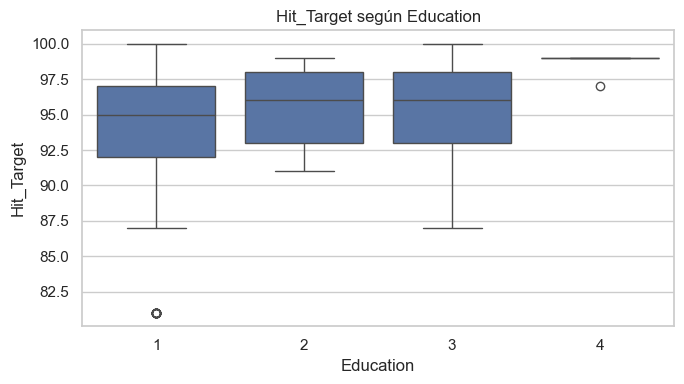

C:\Users\vanes\AppData\Local\Temp\ipykernel_7632\3247932963.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(cat)[num]


,count,mean,median,std
Education,,,,
1,663,12.99,13.0,4.11
2,51,9.37,4.0,6.88
3,86,10.37,9.0,2.43
4,5,15.00,15.0,0.00


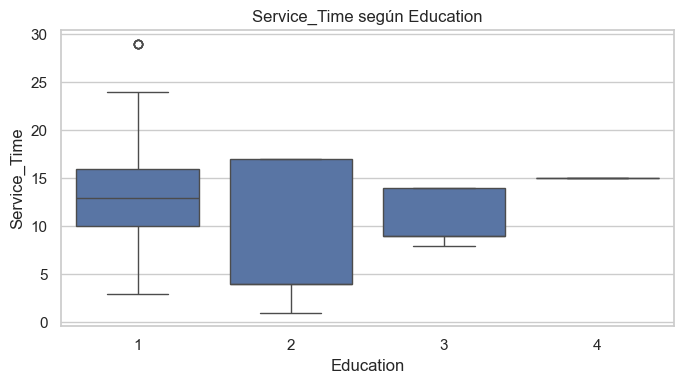

C:\Users\vanes\AppData\Local\Temp\ipykernel_7632\3247932963.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(cat)[num]


,count,mean,median,std
Education,,,,
1,663,7.47,3.0,14.68
2,51,6.73,8.0,6.92
3,86,5.55,3.0,7.74
4,5,4.80,3.0,2.95


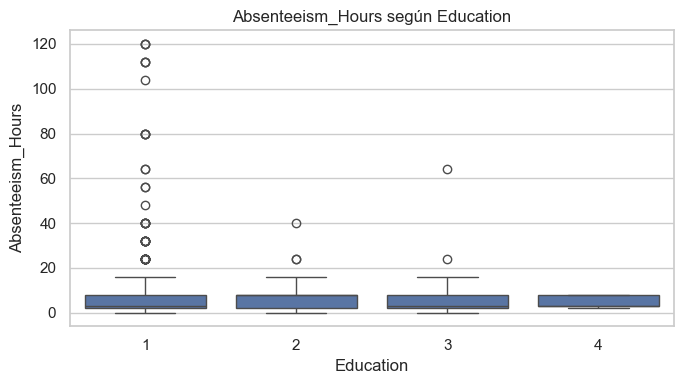

,count,mean,median,std
Disciplinary_Failure,,,,
0,759,7.64,4.0,13.97
1,46,0.00,0.0,0.00


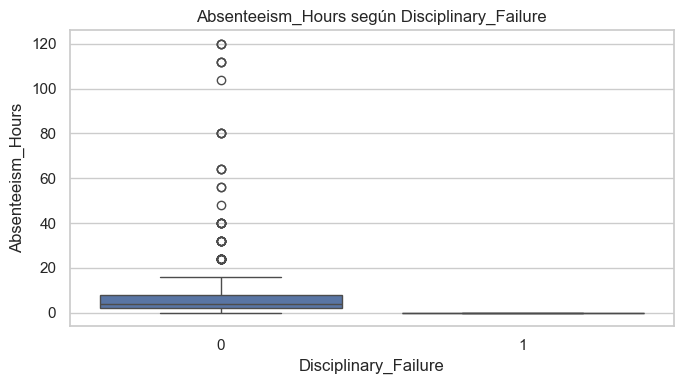

,count,mean,median,std
Disciplinary_Failure,,,,
0,759,94.75,95.0,3.60
1,46,92.57,92.5,5.08


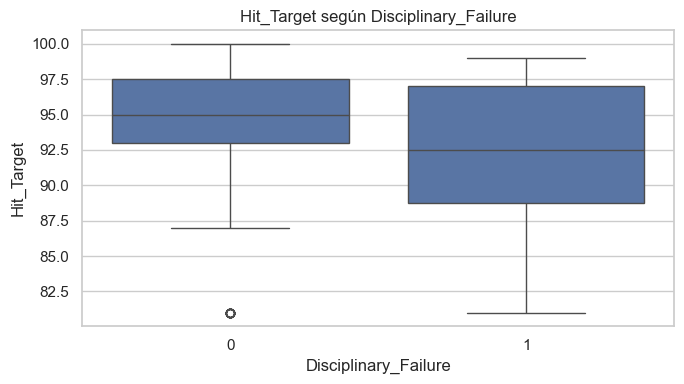

,count,mean,median,std
Social_Drinker,,,,
0,348,25.09,24.0,4.03
1,457,27.81,28.0,4.05


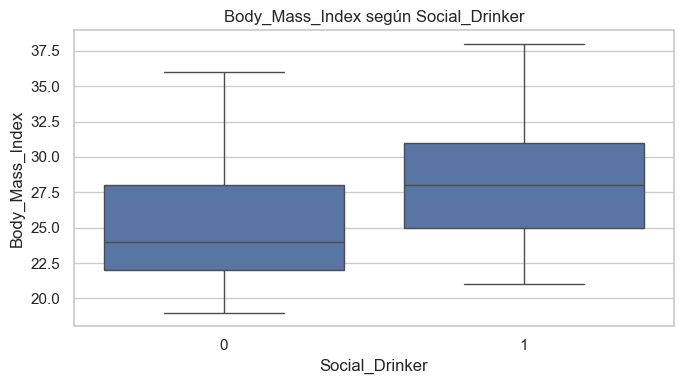

,count,mean,median,std
Social_Smoker,,,,
0,743,7.29,3.0,13.98
1,62,6.16,3.5,9.52


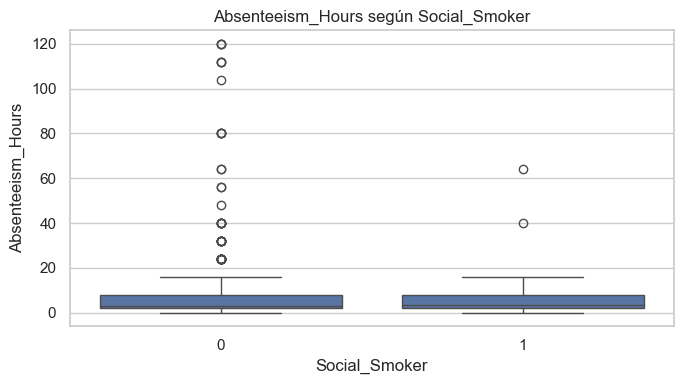

In [29]:
cruces = [
    ("Education", "Hit_Target"),
    ("Education", "Service_Time"),
    ("Education", "Absenteeism_Hours"),
    ("Disciplinary_Failure", "Absenteeism_Hours"),
    ("Disciplinary_Failure", "Hit_Target"),
    ("Social_Drinker", "Body_Mass_Index"),
    ("Social_Smoker", "Absenteeism_Hours")
]

for cat, num in cruces:
    display(
        df.groupby(cat)[num]
        .agg(["count", "mean", "median", "std"])
        .round(2)
    )

    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x=cat, y=num)
    plt.title(f"{num} según {cat}")
    plt.tight_layout()
    plt.show()

### Conclusiones

#### Conclusiones Generales

Se mantiene la validez de las conclusiones del resumen 2026-06-29_EDA.
Hay más registros pero todas las tendencias se mantienen.

Resultados una vez se han eliminado los duplicados y vuelto a ejecutar:

- Total registros: 845 (+105 nuevos)  
- Total: 136 empleados (+100 nuevos)  
- Sin nulos  
- Sigue apareciendo month=0  
- % duplicados se mantiene (4,62% vs 4,59%)  
- Variables numéricas mantienen min y max.  
- Variables categóricas no han sumados categorias nuevas, y frecuencia top se mantiene en cada una.  
- Las distribuciones de todas las variables se mantienen. De hecho, sólo se suman registros a los valores existentes manteniendo la frecuencia general de cada valor.  
- Work_load_Average_day tiene alguns cambios con sus nuevos registros.  



<!-- #### Conclusiones Relaciones

Correlaciones fuertes o relevantes
* Weight y Body_Mass_Index: 0.89
Normal dado que el IMC depende directamente del peso.

* Age y Service_Time: 0.76
Empleados de mayor edad tienden a tener más tiempo de servicio.

    * Body_Mass_Index y Service_time: 0.56

    * Age y Body_mass_index: 0.48

    * Weight y Service_time: 0.53

* Son y Transportation_Expense: 0.42
* Pet y Transportation_Expense: 0.47
Empleado con hijos o mascotas tienden a gastar más en transporte.


Relaciones negativas
* Pet y Service_time: -0.34
Empleados con más tiempo de servicio tienden a tener menos mascotas. 
* Pet y Age: -0.28
Empleados con más edad tienden a tener menos mascotas. 

* Transportation_expense y Service_time: -0.28
A mayor tiempo de servicio, menor gasto de transporte. Podría deberse a perfiles de empleados, ubicación o antigüedad.


Cruces de categóricas

* Reason_absence vs Disciplinary_Failure: 0.962
 Probablemente porque ciertos motivos de ausencia están directamente ligados a fallo disciplinario o ausencia injustificada. Revisaría la tabla cruzada: puede haber una categoría casi exclusiva.

* Education vs Social_Drinker: 0.472
Asociación moderada. El consumo social de alcohol varía según nivel educativo.

* Education vs Social_Smoker: 0.364
Asociación moderada-baja. El hábito de fumar también cambia según educación, aunque menos que beber.

Estas sugieren que los motivos de ausencia no se distribuyen igual según hábitos sociales o estación:
 
* Reason_absence vs Social_Smoker: 0.356
* Reason_absence vs Seasons: 0.347
* Reason_absence vs Social_Drinker: 0.346 -->
